## Importamos todas las librerías que vamos a necesitar

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt


## Importamos los Datasets a df

In [27]:
try:
  # Import the datasets into pandas DataFrames
  df = pd.read_csv('merged_dataset.csv')

  print("Datasets imported successfully!")

except FileNotFoundError:
  print("One or more files not found. Check the file paths.")
except pd.errors.ParserError:
  print("Error parsing one or more CSV files. Check file format.")
except Exception as e:
  print(f"An error occurred: {e}")

Datasets imported successfully!


# Visualización de los datos y análisis exploratorio

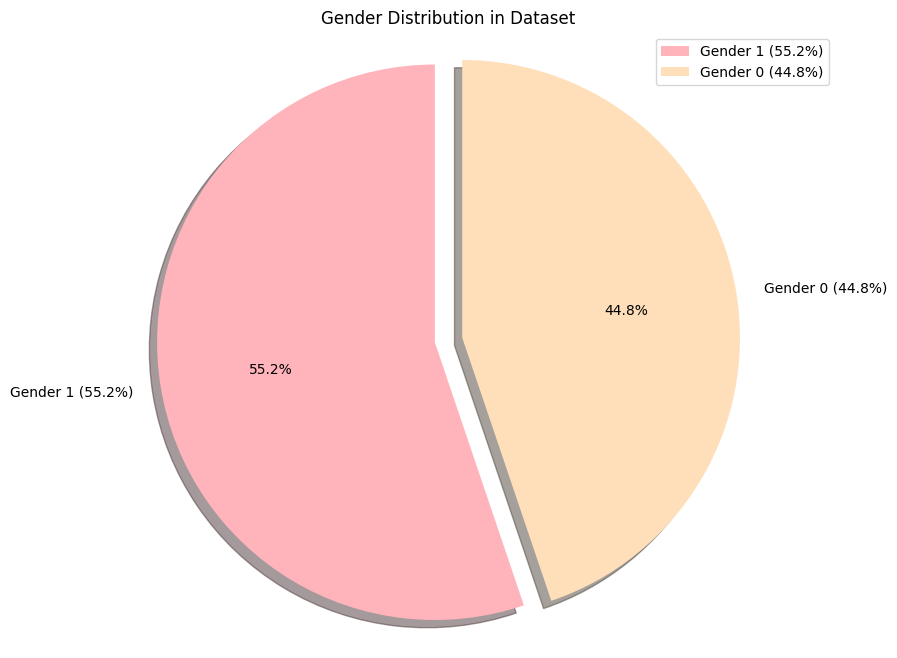

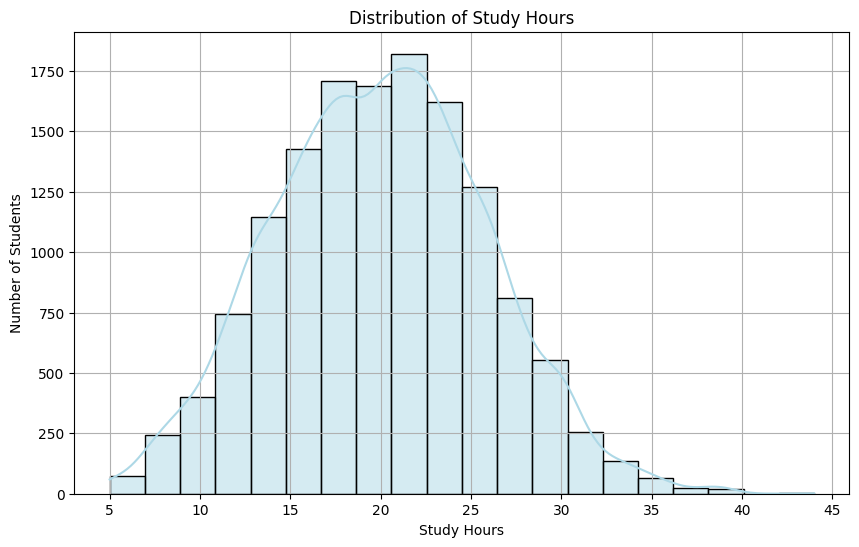

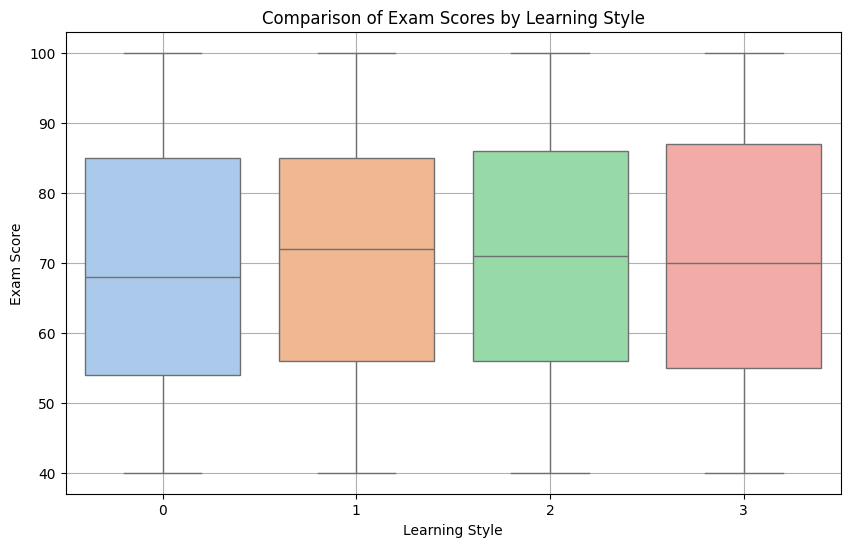

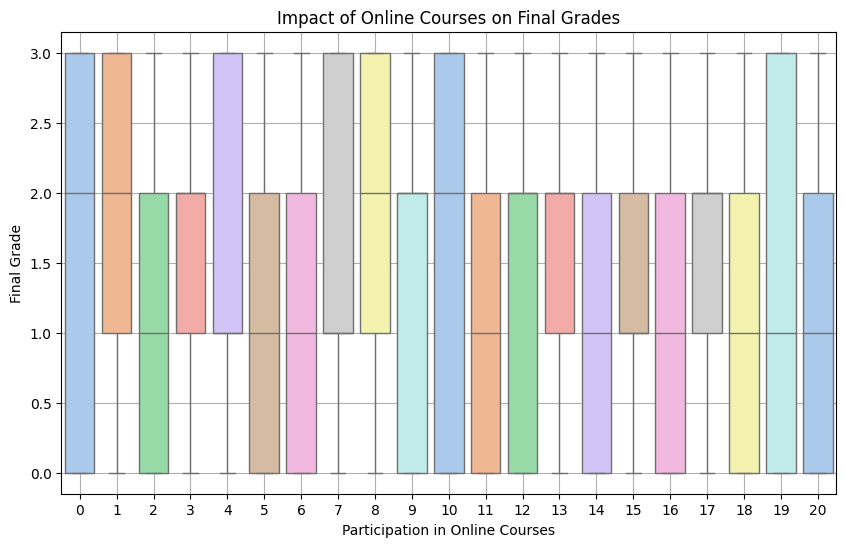

In [28]:
# Gender Distribution Pie Chart
plt.figure(figsize=(10, 8))
gender_counts = df['Gender'].value_counts()

# Calculate percentages
total = gender_counts.sum()
percentages = [f'{(count/total)*100:.1f}%' for count in gender_counts]

# Create pie chart with pastel colors
colors = ['#FFB3BA', '#FFDFBA']  # Pastel colors for gender distribution
plt.pie(gender_counts, labels=[f'Gender {i} ({perc})' for i, perc in zip(gender_counts.index, percentages)],
        autopct='%1.1f%%',
        colors=colors,
        explode=[0.05] * len(gender_counts),  
        shadow=True,
        startangle=90)

plt.title('Gender Distribution in Dataset')
plt.axis('equal') 
plt.legend()
plt.show()

# 1. Distribution of Study Hours
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='StudyHours', bins=20, kde=True, color='lightblue')
plt.title('Distribution of Study Hours')
plt.xlabel('Study Hours')
plt.ylabel('Number of Students')
plt.grid()
plt.show()

# 2. Comparison of Exam Scores by Learning Style
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='LearningStyle', y='ExamScore', hue='LearningStyle', palette='pastel', legend=False)
plt.title('Comparison of Exam Scores by Learning Style')
plt.xlabel('Learning Style')
plt.ylabel('Exam Score')
plt.grid()
plt.show()

# 3. Impact of Online Courses on Final Grades
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='OnlineCourses', y='FinalGrade', hue='OnlineCourses', palette='pastel', legend=False)
plt.title('Impact of Online Courses on Final Grades')
plt.xlabel('Participation in Online Courses')
plt.ylabel('Final Grade')
plt.grid()
plt.show()

# Evaluación del modelo con clustering

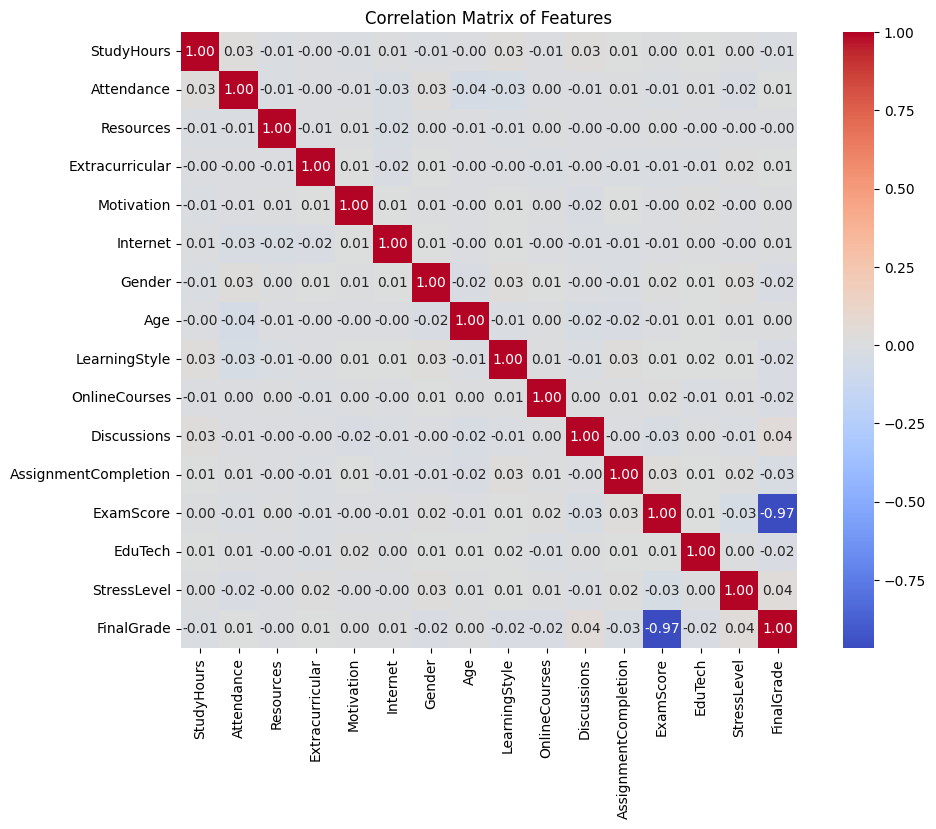

In [37]:
# Step 1: Select all relevant features for correlation analysis
features = df.select_dtypes(include=[np.number])  # Selecting only numeric features

# Step 2: Display the correlation matrix
plt.figure(figsize=(12, 8))
correlation_matrix = features.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Features')
plt.show()

# Modelo  de prueba con árboles de decisión

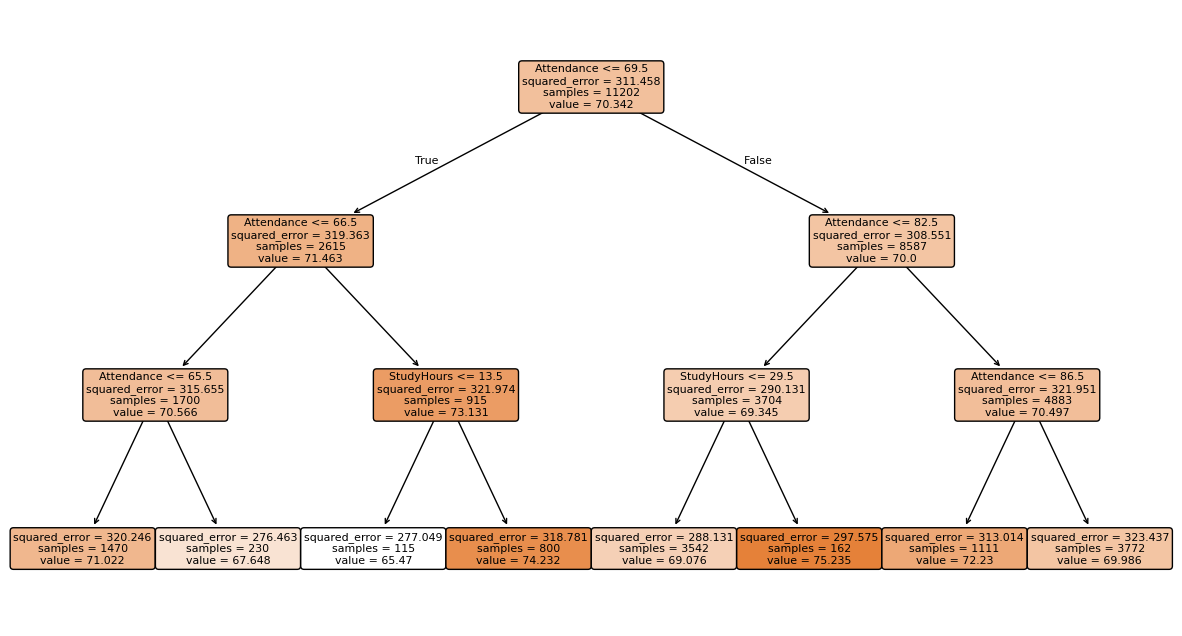

In [32]:

# 1. Seleccionamos variables que influyen directamente
X = df[['StudyHours', 'Attendance', 'Motivation', 'Resources']]
y = df['ExamScore']

# 2. Dividimos los datos para probar el modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenamos un árbol sencillo (limitamos la profundidad para que sea legible)
model = DecisionTreeRegressor(max_depth=3) 
model.fit(X_train, y_train)

# 4. ¡Visualizamos las reglas!
plt.figure(figsize=(15,8))
plot_tree(model, feature_names=X.columns, filled=True, rounded=True)
plt.show()

# Entrenamiento de modelos con distintas estrategias

Cogemos unas columnas que a simple vista nos parecen importantes para hacer el split de train y test.

In [35]:

# Supongamos que X son tus columnas de estudio y y es la nota final
X = df[['StudyHours', 'Attendance', 'Motivation', 'Resources']] 
y = df['ExamScore']

# Dividimos: 80% para entrenar y 20% para evaluar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Probamos tres enfoques distintos para nuestro modelo

In [36]:
# Definimos los competidores
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Árbol de Decisión": DecisionTreeRegressor(max_depth=5),
    "Random Forest": RandomForestRegressor(n_estimators=100)
}

# Probamos cada uno
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train) # Entrenamiento
    predicciones = modelo.predict(X_test) # Predicción
    
    # Métricas
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)
    
    print(f"--- {nombre} ---")
    print(f"Error promedio (MAE): {mae:.2f} puntos")
    print(f"Precisión (R2 Score): {r2:.2f}")
    print("-" * 20)

--- Regresión Lineal ---
Error promedio (MAE): 15.57 puntos
Precisión (R2 Score): -0.00
--------------------
--- Árbol de Decisión ---
Error promedio (MAE): 15.41 puntos
Precisión (R2 Score): 0.02
--------------------
--- Random Forest ---
Error promedio (MAE): 15.42 puntos
Precisión (R2 Score): -0.11
--------------------


# Conclusión

Tal y como hemos visto en la matriz de correlación, no existe prácticamente relación entre las variables y nuestra variable a predecir, por lo que resulta muy complejo hacer un modelo de predicción con alguna de estas estrategias. Es por ese motivo que dejamos estar este dataset, debido a su alta complejidad.